PCA로 가중치 주고 dbscan돌리기
(가중치 주는 과정은 간략화 했습니다 weighted_PCA_kmeans에 좀더 자세히 되어있습니다)

In [1]:
import mglearn
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

In [2]:
df = pd.read_csv('single_variable_data.csv')

In [3]:
health_risk_columns = ['risk_depression', 'risk_drug', 'risk_iadl', 'risk_health', 'risk_age'] #A
infra_gap_columns = ['risk_infra_gap']
aging_rate_columns = ['risk_aging_rate']
economic_instability_columns = ['risk_unemployed', 'risk_subj_econ'] #D
living_conditions_columns = ['risk_housing_env'] #E
social_activities_columns = ['risk_group', 'risk_meet'] #F
self_care_deficit_columns = ['risk_nutrition', 'risk_smoke', 'risk_alcohol']  #G
despair_columns = ['risk_network'] #H

pca_A = PCA(n_components=1)
pca_B = PCA(n_components=1)
pca_C = PCA(n_components=1)
pca_D = PCA(n_components=1)
pca_E = PCA(n_components=1)
pca_F = PCA(n_components=1)
pca_G = PCA(n_components=1)
pca_H = PCA(n_components=1)

PC1_health_risk = pca_A.fit_transform(df[health_risk_columns])
PC1_infra_gap = pca_B.fit_transform(df[infra_gap_columns])
PC1_aging_rate = pca_C.fit_transform(df[aging_rate_columns])
PC1_economic_instability = pca_D.fit_transform(df[economic_instability_columns])
PC1_living_conditions = pca_E.fit_transform(df[living_conditions_columns])
PC1_social_activities = pca_F.fit_transform(df[social_activities_columns])
PC1_self_care_deficit = pca_G.fit_transform(df[self_care_deficit_columns])
PC1_despair = pca_H.fit_transform(df[despair_columns])

health_risk = pd.DataFrame(PC1_health_risk, columns = ['health_risk'])
infra_gap = pd.DataFrame(PC1_infra_gap, columns = ['infra_gap'])
aging_rate = pd.DataFrame(PC1_aging_rate, columns = ['aging_rate'])
economic_instability = pd.DataFrame(PC1_economic_instability, columns = ['economic_instability'])
living_conditions = pd.DataFrame(PC1_living_conditions, columns = ['living_conditions'])
social_activities = pd.DataFrame(PC1_social_activities, columns = ['social_activities'])
self_care_deficit = pd.DataFrame(PC1_self_care_deficit, columns = ['self_care_deficit'])
despair = pd.DataFrame(PC1_despair, columns = ['despair'])

PCA_weighted_df = pd.concat(
    [health_risk, infra_gap, aging_rate, economic_instability, living_conditions, social_activities, self_care_deficit, despair],
    axis=1
)
PCA_weighted_df.head()

,health_risk,infra_gap,aging_rate,economic_instability,living_conditions,social_activities,self_care_deficit,despair
0,-0.284238,0.276049,-0.190163,0.350166,-0.083019,-0.127349,0.150994,-0.026489
1,0.213517,0.276049,-0.190163,0.386214,0.416981,0.628251,-0.845627,0.140178
2,-0.043386,0.276049,-0.190163,-0.611184,0.166981,-0.031568,-0.916249,-0.026489
3,-0.058352,0.276049,-0.190163,0.350166,-0.083019,-0.078744,-0.845627,-0.026489
4,0.657785,0.276049,-0.190163,0.386214,0.416981,-0.361478,0.171966,-0.359822


얼추 hyperparameter 범위 찾기.. ->

In [4]:
for min_sample in [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]:
    for eps in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]:
        dbscan = DBSCAN(eps=eps, min_samples=min_sample)
        labels = dbscan.fit_predict(PCA_weighted_df)
    
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  #클러스터 개수, -1인 label(노이즈)가 있으면 label길이에서 하나뺸거
        n_noise = list(labels).count(-1)  #label중 -1인 애 카운트
        noise_ratio = n_noise / len(labels)
    
        print(f"min sample={min_sample} eps={eps}: clusters={n_clusters}, noise={noise_ratio:.1%}")

min sample=8 eps=1.0: clusters=1, noise=0.0%
min sample=8 eps=1.5: clusters=1, noise=0.0%
min sample=8 eps=2.0: clusters=1, noise=0.0%
min sample=8 eps=2.5: clusters=1, noise=0.0%
min sample=8 eps=3.0: clusters=1, noise=0.0%
min sample=8 eps=4.0: clusters=1, noise=0.0%
min sample=8 eps=5.0: clusters=1, noise=0.0%
min sample=9 eps=1.0: clusters=1, noise=0.0%
min sample=9 eps=1.5: clusters=1, noise=0.0%
min sample=9 eps=2.0: clusters=1, noise=0.0%
min sample=9 eps=2.5: clusters=1, noise=0.0%
min sample=9 eps=3.0: clusters=1, noise=0.0%
min sample=9 eps=4.0: clusters=1, noise=0.0%
min sample=9 eps=5.0: clusters=1, noise=0.0%
min sample=10 eps=1.0: clusters=1, noise=0.0%
min sample=10 eps=1.5: clusters=1, noise=0.0%
min sample=10 eps=2.0: clusters=1, noise=0.0%
min sample=10 eps=2.5: clusters=1, noise=0.0%
min sample=10 eps=3.0: clusters=1, noise=0.0%
min sample=10 eps=4.0: clusters=1, noise=0.0%
min sample=10 eps=5.0: clusters=1, noise=0.0%
min sample=11 eps=1.0: clusters=1, noise=0.0%
mi

In [5]:
for min_sample in [4, 5, 6, 7, 8]:
    for eps in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]:
        dbscan = DBSCAN(eps=eps, min_samples=min_sample)
        labels = dbscan.fit_predict(PCA_weighted_df)
    
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  #클러스터 개수, -1인 label(노이즈)가 있으면 label길이에서 하나뺸거
        n_noise = list(labels).count(-1)  #label중 -1인 애 카운트
        noise_ratio = n_noise / len(labels)
    
        print(f"min sample={min_sample} eps={eps}: clusters={n_clusters}, noise={noise_ratio:.1%}")

min sample=4 eps=1.0: clusters=1, noise=0.0%
min sample=4 eps=1.5: clusters=1, noise=0.0%
min sample=4 eps=2.0: clusters=1, noise=0.0%
min sample=4 eps=2.5: clusters=1, noise=0.0%
min sample=4 eps=3.0: clusters=1, noise=0.0%
min sample=4 eps=4.0: clusters=1, noise=0.0%
min sample=4 eps=5.0: clusters=1, noise=0.0%
min sample=5 eps=1.0: clusters=1, noise=0.0%
min sample=5 eps=1.5: clusters=1, noise=0.0%
min sample=5 eps=2.0: clusters=1, noise=0.0%
min sample=5 eps=2.5: clusters=1, noise=0.0%
min sample=5 eps=3.0: clusters=1, noise=0.0%
min sample=5 eps=4.0: clusters=1, noise=0.0%
min sample=5 eps=5.0: clusters=1, noise=0.0%
min sample=6 eps=1.0: clusters=1, noise=0.0%
min sample=6 eps=1.5: clusters=1, noise=0.0%
min sample=6 eps=2.0: clusters=1, noise=0.0%
min sample=6 eps=2.5: clusters=1, noise=0.0%
min sample=6 eps=3.0: clusters=1, noise=0.0%
min sample=6 eps=4.0: clusters=1, noise=0.0%
min sample=6 eps=5.0: clusters=1, noise=0.0%
min sample=7 eps=1.0: clusters=1, noise=0.0%
min sample

In [6]:
for min_sample in [4, 5, 6, 7, 8, 9]:
    for eps in [0.5, 0.6, 0.7, 0.8]:
        dbscan = DBSCAN(eps=eps, min_samples=min_sample)
        labels = dbscan.fit_predict(PCA_weighted_df)
    
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  #클러스터 개수, -1인 label(노이즈)가 있으면 label길이에서 하나뺸거
        n_noise = list(labels).count(-1)  #label중 -1인 애 카운트
        noise_ratio = n_noise / len(labels)
    
        print(f"min sample={min_sample} eps={eps}: clusters={n_clusters}, noise={noise_ratio:.1%}")

min sample=4 eps=0.5: clusters=2, noise=0.6%
min sample=4 eps=0.6: clusters=2, noise=0.0%
min sample=4 eps=0.7: clusters=2, noise=0.0%
min sample=4 eps=0.8: clusters=1, noise=0.0%
min sample=5 eps=0.5: clusters=2, noise=0.7%
min sample=5 eps=0.6: clusters=2, noise=0.0%
min sample=5 eps=0.7: clusters=2, noise=0.0%
min sample=5 eps=0.8: clusters=1, noise=0.0%
min sample=6 eps=0.5: clusters=2, noise=0.8%
min sample=6 eps=0.6: clusters=2, noise=0.0%
min sample=6 eps=0.7: clusters=2, noise=0.0%
min sample=6 eps=0.8: clusters=1, noise=0.0%
min sample=7 eps=0.5: clusters=2, noise=0.9%
min sample=7 eps=0.6: clusters=2, noise=0.0%
min sample=7 eps=0.7: clusters=2, noise=0.0%
min sample=7 eps=0.8: clusters=1, noise=0.0%
min sample=8 eps=0.5: clusters=2, noise=0.9%
min sample=8 eps=0.6: clusters=2, noise=0.0%
min sample=8 eps=0.7: clusters=2, noise=0.0%
min sample=8 eps=0.8: clusters=1, noise=0.0%
min sample=9 eps=0.5: clusters=2, noise=1.0%
min sample=9 eps=0.6: clusters=2, noise=0.0%
min sample

# k-distance

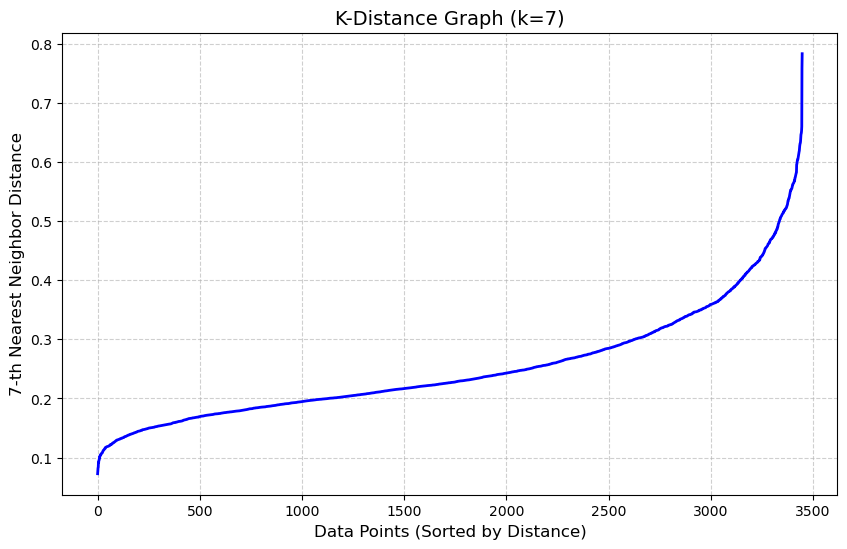

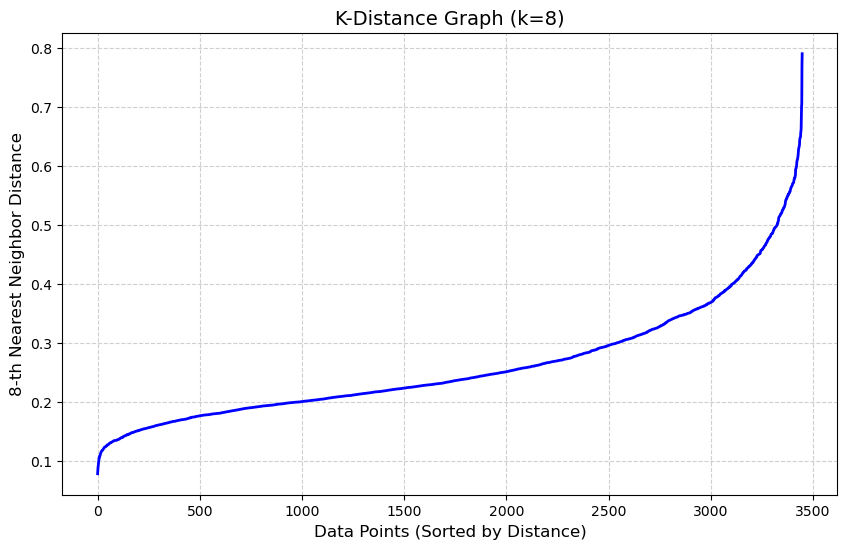

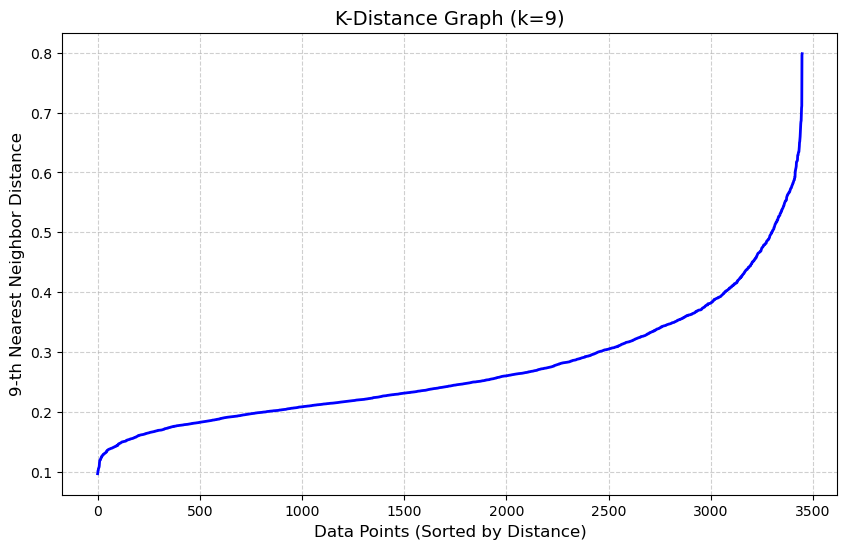

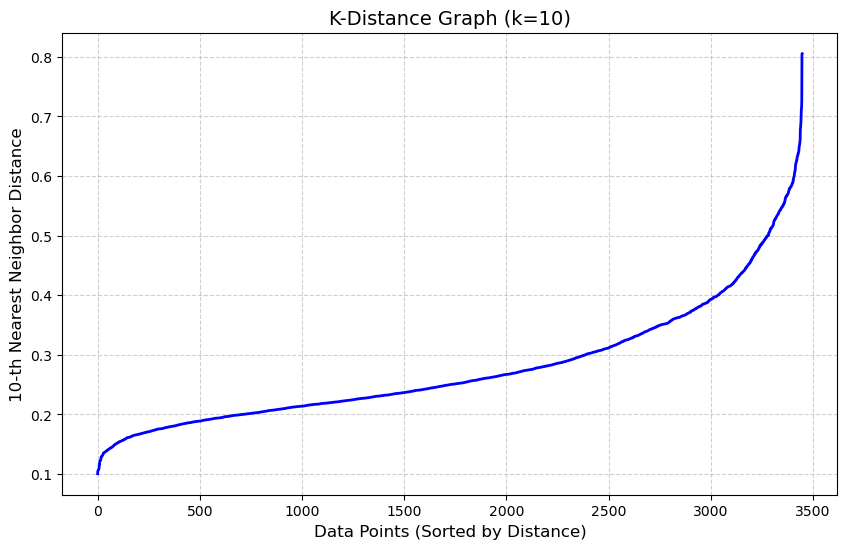

In [7]:
for min_samples in [7, 8, 9, 10]:
    # 3. NearestNeighbors를 통해 각 데이터별로 min_samples번째로 가까운 이웃과의 거리 계산
    # n_neighbors는 자기 자신을 포함하므로 min_samples 값을 그대로 사용합니다.
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(PCA_weighted_df)
    distances, indices = neighbors_fit.kneighbors(PCA_weighted_df)

    # 4. 각 데이터의 '가장 먼 이웃(min_samples번째)'과의 거리만 추출하여 오름차순 정렬
    # distances 배열의 마지막 열([-1])이 가장 먼 이웃과의 거리입니다.
    sort_distances = np.sort(distances[:, -1])

    # 5. K-거리 그래프 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(sort_distances, color='b', lw=2)
    plt.title(f'K-Distance Graph (k={min_samples})', fontsize=14)
    plt.xlabel('Data Points (Sorted by Distance)', fontsize=12)
    plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [4]:
hyp = []

for min_samples in range(5, 13):
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(PCA_weighted_df)
    distances, indices = neighbors_fit.kneighbors(PCA_weighted_df)
    sort_distances = np.sort(distances[:, -1])

    # x축 좌표 생성 (0부터 2999까지)
    x_indices = np.arange(len(sort_distances))

    # KneeLocator 설정
    # S: 민감도 (일반적으로 1.0 사용, 값이 작을수록 미세한 변화에 반응)
    # curve: 'convex' (볼록한 곡선 형태)
    # direction: 'increasing' (우상향하는 그래프)
    kneedle = KneeLocator(
    x_indices, 
    sort_distances, 
    S=1.0, 
    curve='convex', 
    direction='increasing'
    )

    # 최적의 꺾임점 정보 추출
    optimal_x = kneedle.knee
    optimal_eps = kneedle.knee_y
    hyp.append({
        'min_sample': min_samples,
        'eps': optimal_eps
    })

    print(f"최적 eps : {optimal_eps:.4f} (인덱스: {optimal_x})")

hyp = pd.DataFrame(hyp)

최적 eps : 0.4755 (인덱스: 3383)
최적 eps : 0.4655 (인덱스: 3353)
최적 eps : 0.5258 (인덱스: 3396)
최적 eps : 0.4890 (인덱스: 3340)
최적 eps : 0.5427 (인덱스: 3386)
최적 eps : 0.5708 (인덱스: 3407)
최적 eps : 0.5768 (인덱스: 3408)
최적 eps : 0.5609 (인덱스: 3379)


In [5]:
for i in range(len(hyp)):
    min_sample = int(hyp.iloc[i]['min_sample'])
    eps = hyp.iloc[i]['eps']
    
    dbscan = DBSCAN(eps=eps, min_samples=min_sample)
    labels = dbscan.fit_predict(PCA_weighted_df)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  #클러스터 개수, -1인 label(노이즈)가 있으면 label길이에서 하나뺸거
    n_noise = list(labels).count(-1)  #label중 -1인 애 카운트
    noise_ratio = n_noise / len(labels)
    
    print(f"min sample={min_sample} eps={eps}: clusters={n_clusters}, noise={noise_ratio:.1%}")  

min sample=5 eps=0.47548750665391426: clusters=2, noise=0.6%
min sample=6 eps=0.4655280740442927: clusters=2, noise=0.9%
min sample=7 eps=0.5257720468422017: clusters=2, noise=0.3%
min sample=8 eps=0.48903914277328986: clusters=2, noise=0.6%
min sample=9 eps=0.5426773749874806: clusters=2, noise=0.2%
min sample=10 eps=0.5708299809631088: clusters=2, noise=0.1%
min sample=11 eps=0.5767936770549309: clusters=2, noise=0.0%
min sample=12 eps=0.5608802732429092: clusters=2, noise=0.2%


In [6]:
for i in range(len(hyp)):
    min_sample = int(hyp.iloc[i]['min_sample'])
    eps = hyp.iloc[i]['eps']
    
    dbscan = DBSCAN(eps=eps, min_samples=min_sample)  
    labels = dbscan.fit_predict(PCA_weighted_df)
    mask = labels != -1
    sil_score = silhouette_score(PCA_weighted_df[mask], labels[mask])
    print(f"\n eps: {eps} min_sample: {min_sample} 실루엣 스코어 : {sil_score:.4f}")


 eps: 0.47548750665391426 min_sample: 5 실루엣 스코어 : 0.3400

 eps: 0.4655280740442927 min_sample: 6 실루엣 스코어 : 0.3405

 eps: 0.5257720468422017 min_sample: 7 실루엣 스코어 : 0.3392

 eps: 0.48903914277328986 min_sample: 8 실루엣 스코어 : 0.3401

 eps: 0.5426773749874806 min_sample: 9 실루엣 스코어 : 0.3391

 eps: 0.5708299809631088 min_sample: 10 실루엣 스코어 : 0.3387

 eps: 0.5767936770549309 min_sample: 11 실루엣 스코어 : 0.3387

 eps: 0.5608802732429092 min_sample: 12 실루엣 스코어 : 0.3390


죄다 클러스터가 2개로 나옴